<a href="https://colab.research.google.com/github/chicket566/Bank-Marketing/blob/main/bank_marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ACCESSING THE DATA

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [11]:
df.nunique()

,0
age,47
sex,2
bmi,548
children,6
smoker,2
region,4
charges,1337


In [12]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [13]:
df["sex"].value_counts()

,count
sex,
male,675
female,662


In [14]:
df["children"].value_counts()

,count
children,
0,573
1,324
2,240
3,157
4,25
5,18


In [15]:
df["smoker"].value_counts()

,count
smoker,
no,1063
yes,274


In [16]:
df["region"].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


EXPLORATORY DATA ANALYSIS(EDA)

<Axes: xlabel='charges', ylabel='Count'>

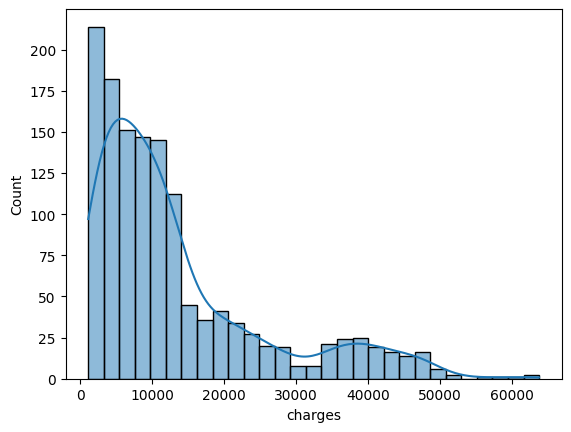

In [17]:
sns.histplot(data=df["charges"],kde=True)

<Axes: xlabel='age', ylabel='Count'>

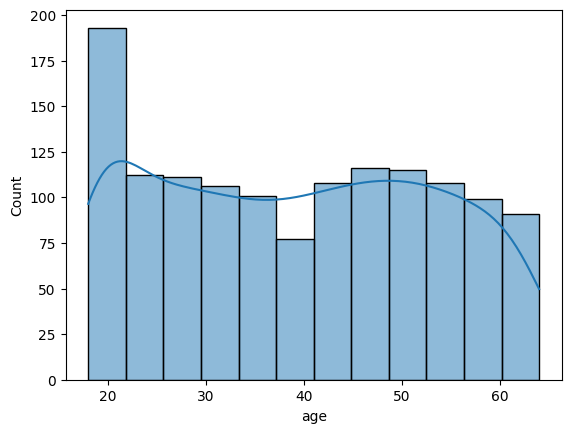

In [18]:
sns.histplot(df["age"], kde=True)

<Axes: xlabel='bmi', ylabel='Count'>

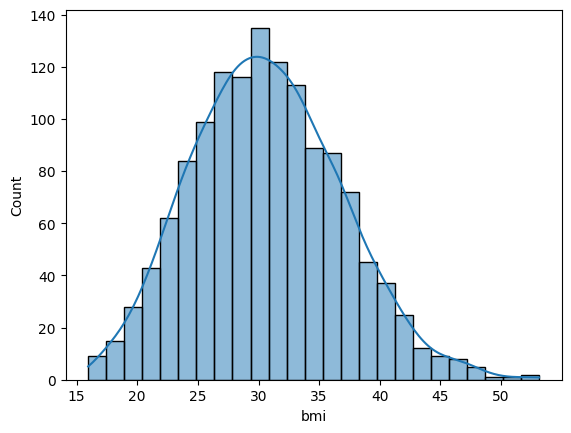

In [19]:
sns.histplot(df["bmi"], kde=True)

<Axes: xlabel='children', ylabel='count'>

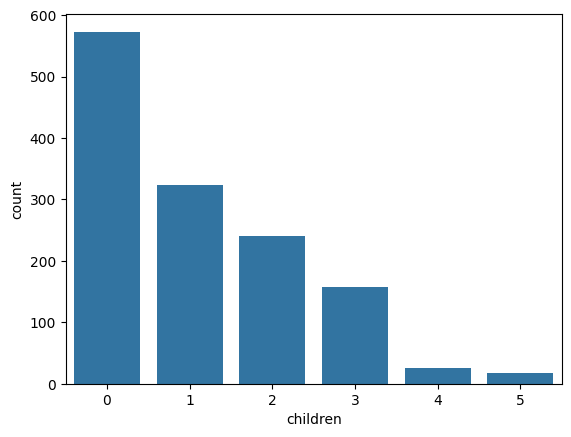

In [20]:
sns.countplot(x="children", data=df)

<Axes: xlabel='age'>

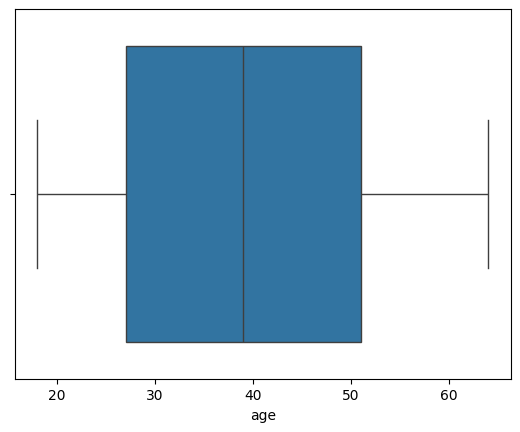

In [21]:
sns.boxplot(x=df["age"])

<Axes: xlabel='bmi'>

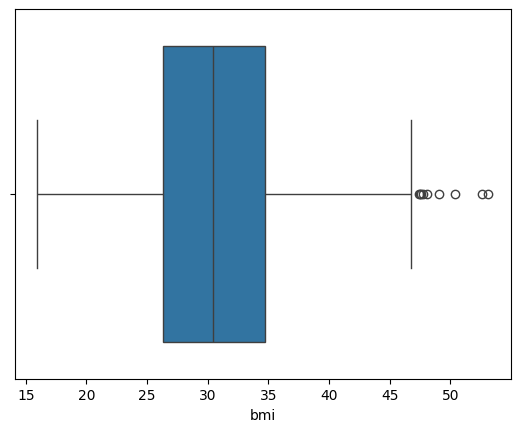

In [22]:
sns.boxplot(x=df["bmi"])

<Axes: xlabel='charges'>

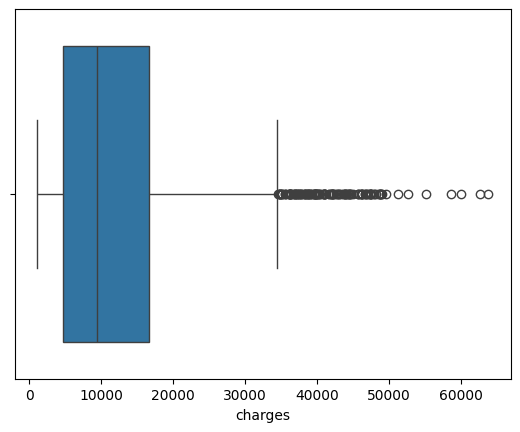

In [23]:
sns.boxplot(x=df["charges"])

In [24]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


<Axes: >

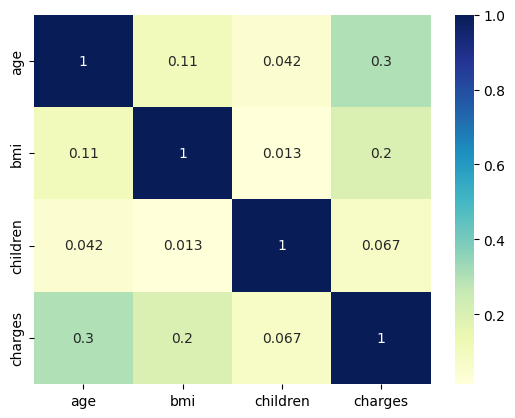

In [25]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="YlGnBu")

<Axes: xlabel='age', ylabel='charges'>

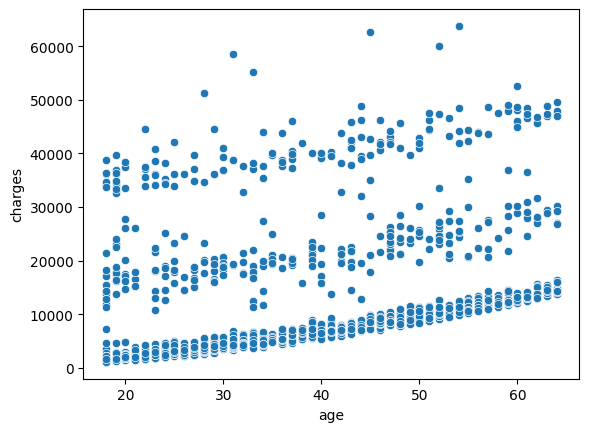

In [26]:
sns.scatterplot(data=df,x="age",y="charges")

<Axes: xlabel='bmi', ylabel='charges'>

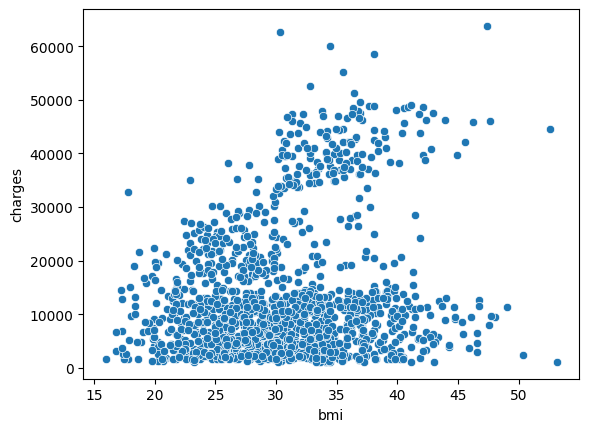

In [27]:
sns.scatterplot(data=df,x="bmi",y="charges")

<Axes: xlabel='sex', ylabel='charges'>

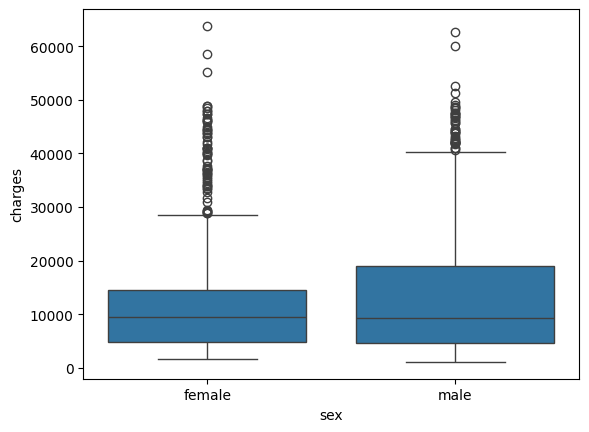

In [28]:
sns.boxplot(x="sex",y="charges",data=df)

<Axes: xlabel='smoker', ylabel='charges'>

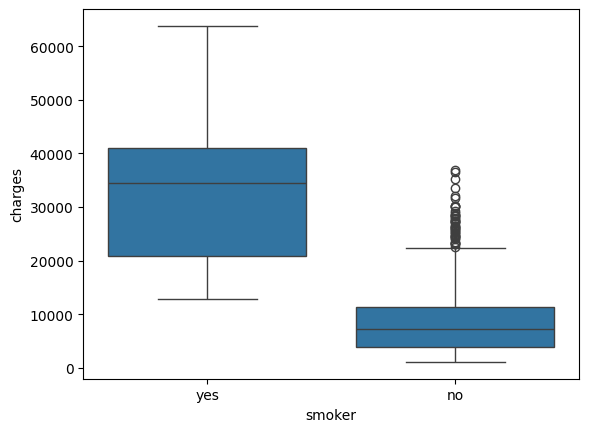

In [29]:
sns.boxplot(x="smoker",y="charges",data=df)

<Axes: xlabel='region', ylabel='charges'>

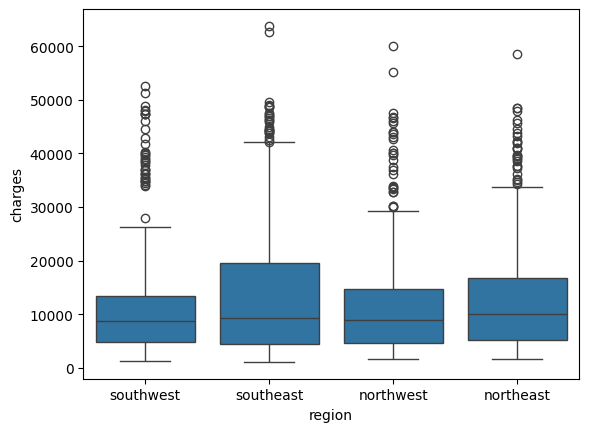

In [30]:
sns.boxplot(x="region",y="charges",data=df)

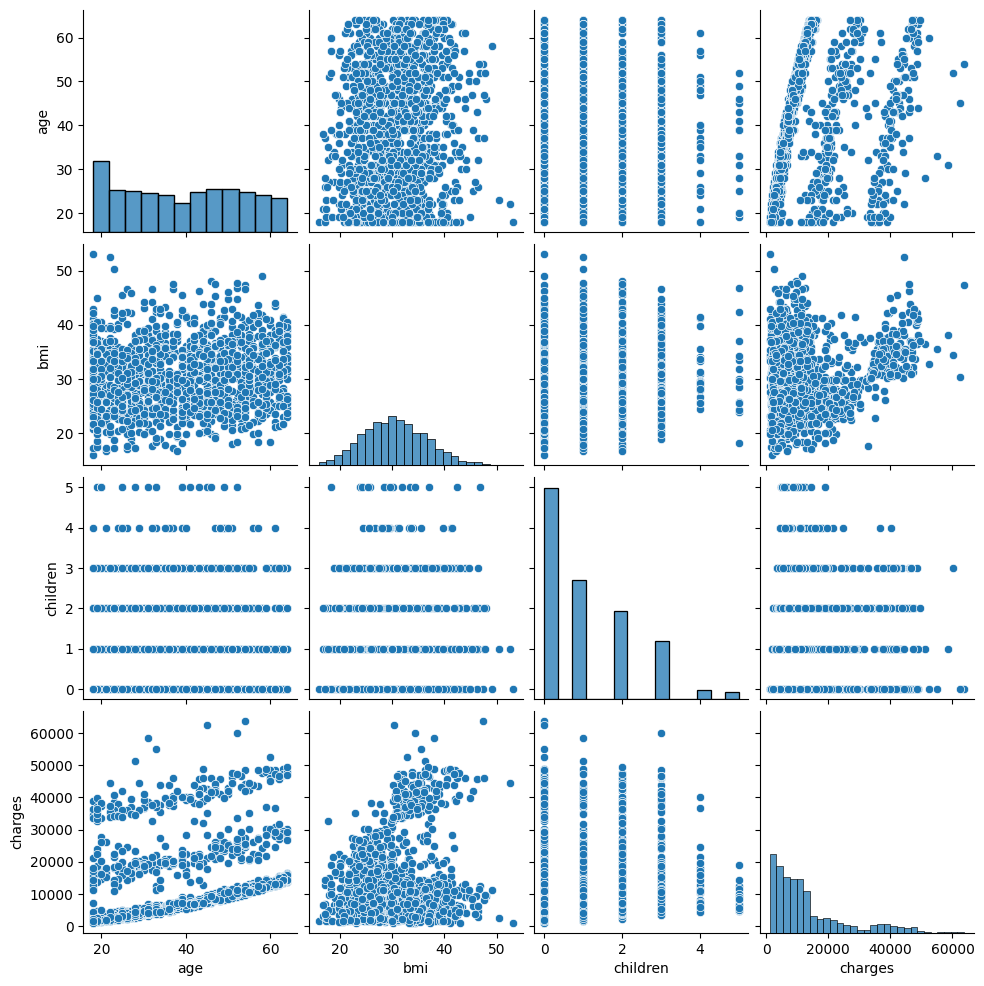

In [31]:
sns.pairplot(df,vars=["age","bmi","children","charges"])

<Axes: xlabel='age', ylabel='charges'>

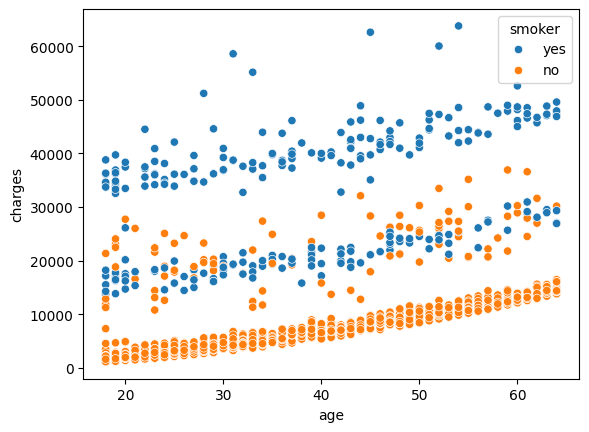

In [32]:
sns.scatterplot(data=df,x="age",y="charges",hue="smoker")

In [33]:
df["charges"].skew()

np.float64(1.5153909108403483)

In [34]:
df["smoker"]=(df["smoker"]=="yes").astype(int)

In [35]:
df=pd.get_dummies(df,columns=["sex","region"],dtype=int)

In [36]:
df

,age,bmi,children,smoker,charges,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1,16884.92400,1,0,0,0,0,1
1,18,33.770,1,0,1725.55230,0,1,0,0,1,0
2,28,33.000,3,0,4449.46200,0,1,0,0,1,0
3,33,22.705,0,0,21984.47061,0,1,0,1,0,0
4,32,28.880,0,0,3866.85520,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,0,10600.54830,0,1,0,1,0,0
1334,18,31.920,0,0,2205.98080,1,0,1,0,0,0
1335,18,36.850,0,0,1629.83350,1,0,0,0,1,0
1336,21,25.800,0,0,2007.94500,1,0,0,0,0,1


In [37]:
X=df.drop("charges",axis=1)
y=df["charges"]

In [38]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split( X,y,test_size=0.2,random_state=42)

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


normal_model = Pipeline([
("scaler",StandardScaler()),
("model",LinearRegression())
])

In [40]:
normal_model.fit(X_train,y_train)
y_pred=normal_model.predict(X_test)

In [41]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mean_absolute_error(y_test,y_pred)

4177.045561036326

In [42]:
mean_squared_error(y_test,y_pred)

35478020.67523561

In [43]:
r2_score(y_test,y_pred)

0.8069287081198011

In [44]:
r2_score(y_train,normal_model.predict(X_train))

0.7299057809339075

In [45]:
r2_score(y_test,normal_model.predict(X_test))

0.8069287081198011

In [47]:
normal_model.named_steps["model"].coef_

array([3472.97555343, 1927.82825101,  636.5011853 , 9234.34248701,
         25.37483733,  -25.37483733,  204.4518162 ,   38.4922327 ,
       -158.60890886,  -76.91034962])

In [48]:
print(normal_model.score(X_train, y_train))
print(normal_model.score(X_test, y_test))

0.7299057809339075
0.8069287081198011


In [49]:
residuals=y_test-y_pred

Text(0.5, 0, 'Residuals')

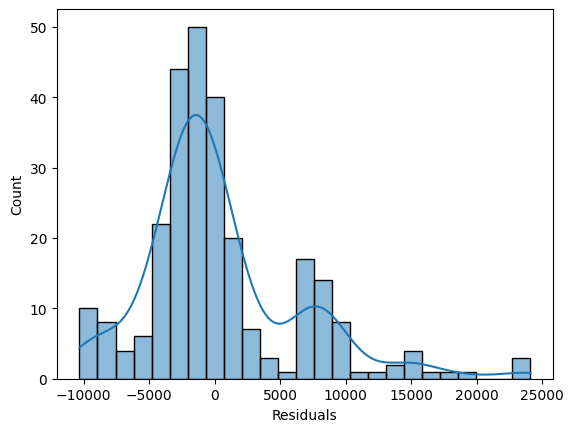

In [50]:
sns.histplot(residuals,kde=True)
plt.xlabel("Residuals")

Text(0.5, 0, 'Residuals')

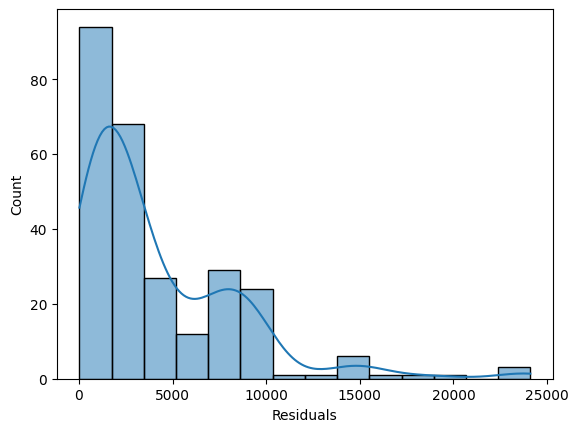

In [51]:
sns.histplot(np.abs(residuals),kde=True)
plt.xlabel("Residuals")

In [52]:
residuals.mean()

np.float64(425.2569948432576)

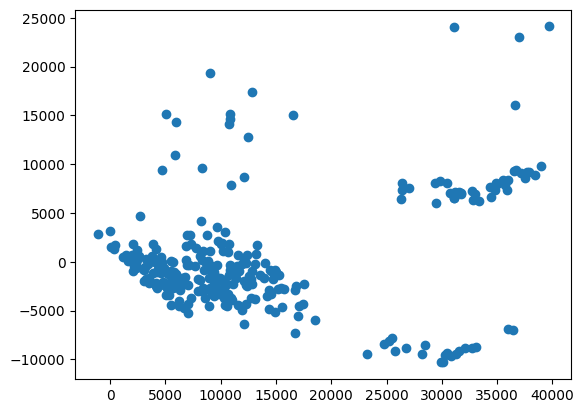

In [53]:
plt.scatter(y_pred, residuals)

In [54]:
absolute_error=np.abs(residuals)

In [55]:
error_df=pd.DataFrame({"Actual":y_test,"Predicted":y_pred,"Residual":residuals,"absolute error":absolute_error})
error_df.sort_values(by="absolute error",ascending=False).head(15)

,Actual,Predicted,Residual,absolute error
543,63770.42801,39659.206889,24111.221121,24111.221121
819,55135.40209,31107.766807,24027.635283,24027.635283
1230,60021.39897,36988.215397,23033.183573,23033.183573
987,28340.18885,9028.579983,19311.608867,19311.608867
115,30259.99556,12811.716568,17448.278992,17448.278992
1146,52590.82939,36570.480968,16020.348422,16020.348422
306,20177.67113,5028.417723,15149.253407,15149.253407
289,25992.82104,10886.591494,15106.229546,15106.229546
573,31620.00106,16576.757460,15043.243600,15043.243600
980,25517.11363,10856.333218,14660.780412,14660.780412


In [57]:
normal_model.named_steps["model"]

LinearRegression()

In [58]:
from sklearn.linear_model import Ridge

pipe = Pipeline([
("scaler",StandardScaler()),
("model",Ridge())
])
param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}
scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error"
}

In [59]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(pipe,param_grid,cv=5,scoring=scoring,refit="r2")
grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', Ridge())]),
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
             refit='r2',
             scoring={'mae': 'neg_mean_absolute_error',
                      'mse': 'neg_mean_squared_error', 'r2': 'r2'})

In [60]:
ridge_best_model=grid.best_estimator_

In [61]:
y_pred = ridge_best_model.predict(X_test)

In [62]:
print("r2 =",r2_score(y_test,y_pred))
print("mae =",mean_absolute_error(y_test,y_pred))
print("mse =",mean_squared_error(y_test,y_pred))

r2 = 0.8050408692383275
mae = 4202.458448823848
mse = 35824922.51763896


In [63]:
print(grid.score(X_train, y_train))
print(grid.score(X_test, y_test))

0.7298397965044804
0.8050408692383275


In [64]:
ridge_best_model.named_steps["model"].coef_

array([3440.28296728, 1908.32148251,  634.4253484 , 9145.49087137,
         21.60586414,  -21.60586414,  201.79811557,   33.04130861,
       -149.23979011,  -78.47008632])

In [65]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient":grid.best_estimator_.named_steps["model"].coef_
})

print(coef_df)

            Feature  Coefficient
0               age  3440.282967
1               bmi  1908.321483
2          children   634.425348
3            smoker  9145.490871
4        sex_female    21.605864
5          sex_male   -21.605864
6  region_northeast   201.798116
7  region_northwest    33.041309
8  region_southeast  -149.239790
9  region_southwest   -78.470086


In [66]:
results=pd.DataFrame(grid.cv_results_)
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,params,split0_test_r2,split1_test_r2,split2_test_r2,split3_test_r2,...,std_test_mae,rank_test_mae,split0_test_mse,split1_test_mse,split2_test_mse,split3_test_mse,split4_test_mse,mean_test_mse,std_test_mse,rank_test_mse
0,0.007116,0.002201,0.004970,0.000738,0.001,{'model__alpha': 0.001},0.694100,0.763572,0.721076,0.705792,...,150.018571,1,-4.649740e+07,-3.258385e+07,-3.368808e+07,-3.773018e+07,-3.715667e+07,-3.753124e+07,4.895273e+06,5
1,0.005615,0.000150,0.004382,0.000164,0.010,{'model__alpha': 0.01},0.694099,0.763572,0.721077,0.705794,...,150.018238,2,-4.649752e+07,-3.258386e+07,-3.368796e+07,-3.772997e+07,-3.715680e+07,-3.753122e+07,4.895332e+06,4
2,0.005686,0.000146,0.004302,0.000034,0.100,{'model__alpha': 0.1},0.694091,0.763572,0.721087,0.705811,...,150.014931,3,-4.649877e+07,-3.258392e+07,-3.368679e+07,-3.772781e+07,-3.715803e+07,-3.753106e+07,4.895921e+06,3
3,0.005754,0.000174,0.004330,0.000090,1.000,{'model__alpha': 1},0.694008,0.763566,0.721182,0.705978,...,149.984104,4,-4.651130e+07,-3.258468e+07,-3.367529e+07,-3.770640e+07,-3.717048e+07,-3.752963e+07,4.901818e+06,2
4,0.005765,0.000389,0.004507,0.000494,10.000,{'model__alpha': 10},0.693116,0.763411,0.722016,0.707523,...,149.941707,5,-4.664697e+07,-3.260616e+07,-3.357459e+07,-3.750827e+07,-3.730554e+07,-3.752831e+07,4.961038e+06,1
5,0.005657,0.000113,0.004637,0.000604,100.000,{'model__alpha': 100},0.678920,0.753966,0.720920,0.712839,...,167.761877,6,-4.880468e+07,-3.390779e+07,-3.370693e+07,-3.682652e+07,-3.948072e+07,-3.854533e+07,5.549784e+06,6
6,0.005860,0.000196,0.004514,0.000141,1000.000,{'model__alpha': 1000},0.471403,0.532768,0.526445,0.540057,...,300.116378,7,-8.034770e+07,-6.439267e+07,-5.719544e+07,-5.898466e+07,-7.173906e+07,-6.653191e+07,8.563848e+06,7


In [67]:
results["mean_test_mae"] = -results["mean_test_mae"]
results["mean_test_mse"] = -results["mean_test_mse"]

In [68]:
results[["param_model__alpha","mean_test_r2","mean_test_mae","mean_test_mse"]]

,param_model__alpha,mean_test_r2,mean_test_mae,mean_test_mse
0,0.001,0.725757,4206.690567,3.753124e+07
1,0.010,0.725758,4206.701731,3.753122e+07
2,0.100,0.725759,4206.813352,3.753106e+07
3,1.000,0.725777,4207.928274,3.752963e+07
4,10.000,0.725857,4219.238992,3.752831e+07
5,100.000,0.718979,4375.138576,3.854533e+07
6,1000.000,0.515377,5931.689091,6.653191e+07


In [69]:
from sklearn.linear_model import Lasso


pipe = Pipeline([
    ("Scaler", StandardScaler()),
    ("model", Lasso(max_iter=10000))
])
param_grid = {
    "model__alpha":[0.001,0.01,0.1,1,10,100]}
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.016e+09, tolerance: 1.205e+07
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.409e+07, tolerance: 1.189e+07
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.069e+09, tolerance: 1.154e

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('Scaler', StandardScaler()),
                                       ('model', Lasso(max_iter=10000))]),
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [70]:
lasso_best_model=grid.best_estimator_

In [71]:
y_pred = lasso_best_model.predict(X_test)

In [72]:
from sklearn.metrics import mean_absolute_error,r2_score

print("MAE =",mean_absolute_error(y_test,y_pred))
print("R² =",r2_score(y_test,y_pred))

MAE = 4179.140815781409
R² = 0.8065114539831848


In [73]:
grid.best_estimator_.named_steps["model"].coef_

array([ 3.46531518e+03,  1.91286938e+03,  6.27812728e+02,  9.22197236e+03,
        3.89923592e+01, -7.48695358e-14,  2.64403533e+02,  9.93871247e+01,
       -7.59387404e+01, -0.00000000e+00])

In [74]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": grid.best_estimator_.named_steps["model"].coef_
})

coef_df["coef_rounded"] = coef_df["Coefficient"].round(2)

print(coef_df)

            Feature   Coefficient  coef_rounded
0               age  3.465315e+03       3465.32
1               bmi  1.912869e+03       1912.87
2          children  6.278127e+02        627.81
3            smoker  9.221972e+03       9221.97
4        sex_female  3.899236e+01         38.99
5          sex_male -7.486954e-14         -0.00
6  region_northeast  2.644035e+02        264.40
7  region_northwest  9.938712e+01         99.39
8  region_southeast -7.593874e+01        -75.94
9  region_southwest -0.000000e+00         -0.00


In [75]:
coef_df[coef_df["coef_rounded"]!=0]

,Feature,Coefficient,coef_rounded
0,age,3465.315182,3465.32
1,bmi,1912.869384,1912.87
2,children,627.812728,627.81
3,smoker,9221.972364,9221.97
4,sex_female,38.992359,38.99
6,region_northeast,264.403533,264.40
7,region_northwest,99.387125,99.39
8,region_southeast,-75.938740,-75.94


In [76]:
param_grid = [
    {
        "model": [LinearRegression()]
    },
    {
        "model": [Ridge()],
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
    {
        "model": [Lasso(max_iter=10000)],
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    }
]
scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error"
}
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring=scoring,
    refit="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('Scaler', StandardScaler()),
                                       ('model', Lasso(max_iter=10000))]),
             n_jobs=-1,
             param_grid=[{'model': [LinearRegression()]},
                         {'model': [Ridge()],
                          'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
                         {'model': [Lasso(max_iter=10000)],
                          'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100,
                                           1000]}],
             refit='r2',
             scoring={'mae': 'neg_mean_absolute_error',
                      'mse': 'neg_mean_squared_error', 'r2': 'r2'})

In [77]:
combined_best_model_linear_ridge_lasso_without_poly_features=grid.best_estimator_

In [78]:
results = pd.DataFrame(grid.cv_results_)

results["mean_test_mae"] = -results["mean_test_mae"]
results["mean_test_mse"] = -results["mean_test_mse"]

results_table = results[
    [
        "param_model",
        "param_model__alpha",
        "mean_test_r2",
        "mean_test_mae",
        "mean_test_mse"
    ]
]

results_table.sort_values("mean_test_r2", ascending=False)

,param_model,param_model__alpha,mean_test_r2,mean_test_mae,mean_test_mse
5,Ridge(),10.000,0.725857,4219.238992,3.752831e+07
12,Lasso(max_iter=10000),10.000,0.725808,4205.514877,3.752560e+07
4,Ridge(),1.000,0.725777,4207.928274,3.752963e+07
13,Lasso(max_iter=10000),100.000,0.725765,4200.929587,3.754224e+07
11,Lasso(max_iter=10000),1.000,0.725764,4206.562917,3.753048e+07
3,Ridge(),0.100,0.725759,4206.813352,3.753106e+07
10,Lasso(max_iter=10000),0.100,0.725758,4206.676626,3.753116e+07
2,Ridge(),0.010,0.725758,4206.701731,3.753122e+07
9,Lasso(max_iter=10000),0.010,0.725757,4206.688038,3.753123e+07
1,Ridge(),0.001,0.725757,4206.690567,3.753124e+07


In [79]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", Ridge())
])
param_grid = [
    {
        "model": [LinearRegression()]
    },
    {
        "poly__degree": [1, 2, 3],
        "model": [Ridge()],
        "model__alpha": [0.01, 0.1, 1, 10, 100]
    },
    {
        "poly__degree": [1, 2, 3],
        "model": [Lasso(max_iter=10000)],
        "model__alpha": [0.01, 0.1, 1, 10, 100]
    }
]
scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error"
}
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring=scoring,
    refit="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('poly',
                                        PolynomialFeatures(include_bias=False)),
                                       ('scaler', StandardScaler()),
                                       ('model', Ridge())]),
             n_jobs=-1,
             param_grid=[{'model': [LinearRegression()]},
                         {'model': [Ridge()],
                          'model__alpha': [0.01, 0.1, 1, 10, 100],
                          'poly__degree': [1, 2, 3]},
                         {'model': [Lasso(max_iter=10000)],
                          'model__alpha': [0.01, 0.1, 1, 10, 100],
                          'poly__degree': [1, 2, 3]}],
             refit='r2',
             scoring={'mae': 'neg_mean_absolute_error',
                      'mse': 'neg_mean_squared_error', 'r2': 'r2'})

In [80]:
import pandas as pd

results = pd.DataFrame(grid.cv_results_)

results["mean_test_mae"] = -results["mean_test_mae"]
results["mean_test_mse"] = -results["mean_test_mse"]

results_table = results[
    [
        "param_poly__degree",
        "param_model",
        "param_model__alpha",
        "mean_test_r2",
        "mean_test_mae",
        "mean_test_mse"
    ]
]

results_table.sort_values("mean_test_r2", ascending=False)

,param_poly__degree,param_model,param_model__alpha,mean_test_r2,mean_test_mae,mean_test_mse
26,2.0,Lasso(max_iter=10000),10.00,0.823206,2963.881023,2.423198e+07
23,2.0,Lasso(max_iter=10000),1.00,0.822721,2979.274745,2.429290e+07
8,2.0,Ridge(),1.00,0.822682,2983.232752,2.429871e+07
5,2.0,Ridge(),0.10,0.822648,2981.926534,2.430246e+07
20,2.0,Lasso(max_iter=10000),0.10,0.822636,2981.637656,2.430409e+07
2,2.0,Ridge(),0.01,0.822627,2981.944904,2.430531e+07
17,2.0,Lasso(max_iter=10000),0.01,0.822624,2981.941349,2.430562e+07
0,NaN,LinearRegression(),NaN,0.822624,2981.949032,2.430566e+07
27,3.0,Lasso(max_iter=10000),10.00,0.818260,3022.203119,2.489816e+07
12,3.0,Ridge(),10.00,0.818247,3044.665442,2.488750e+07


In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R²:", r2_score(y_test, y_pred))

MAE: 2836.8359826910523
MSE: 21346817.55722857
RMSE: 4620.261632984497
R²: 0.8838306769976632


In [82]:
print("Train R²:", best_model.score(X_train, y_train))
print("Test R²:", best_model.score(X_test, y_test))

Train R²: 0.8333306148111841
Test R²: 0.8838306769976632


In [83]:
feature_names = best_model.named_steps["poly"].get_feature_names_out(X.columns)
coef = best_model.named_steps["model"].coef_
coef_df = pd.DataFrame({"Feature": feature_names, "Coefficient": coef})
coef_df["coef_rounded"] = coef_df["Coefficient"].round(2)
coef_df.sort_values("Coefficient",key=abs,ascending=False).head(20)

,Feature,Coefficient,coef_rounded
22,bmi smoker,17877.019826,17877.02
37,smoker^2,-7620.766721,-7620.77
10,age^2,4079.429101,4079.43
1,bmi,1546.597610,1546.60
20,bmi^2,-1534.523831,-1534.52
27,bmi region_southeast,-1132.608460,-1132.61
16,age region_northeast,-801.282238,-801.28
21,bmi children,717.175484,717.18
8,region_southeast,593.295093,593.30
25,bmi region_northeast,531.810722,531.81


In [84]:
coef_df[coef_df["coef_rounded"]!=0]

,Feature,Coefficient,coef_rounded
0,age,-206.060763,-206.06
1,bmi,1546.597610,1546.60
2,children,138.711541,138.71
3,smoker,-51.755020,-51.76
7,region_northwest,-12.722077,-12.72
8,region_southeast,593.295093,593.30
9,region_southwest,-112.562814,-112.56
10,age^2,4079.429101,4079.43
11,age bmi,9.815381,9.82
12,age children,-100.353907,-100.35


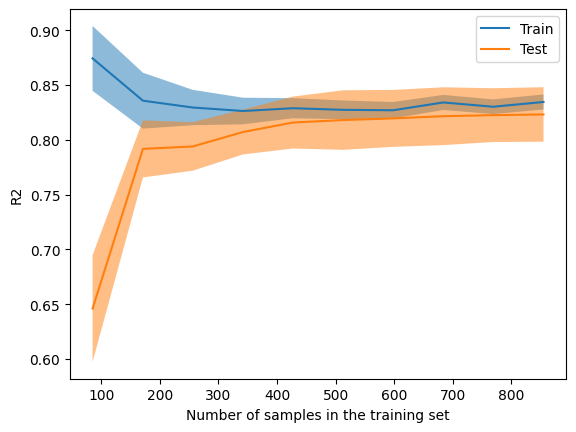

In [85]:
from sklearn.model_selection import LearningCurveDisplay

LearningCurveDisplay.from_estimator(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.show()

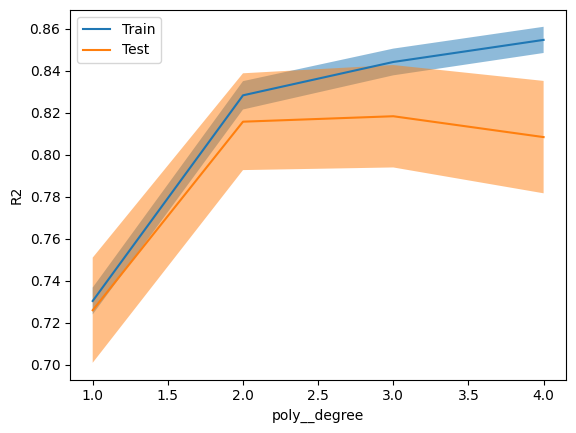

In [86]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ValidationCurveDisplay
import matplotlib.pyplot as plt
import numpy as np

pipe = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10))
])
ValidationCurveDisplay.from_estimator(
    pipe,
    X_train,
    y_train,
    param_name="poly__degree",
    param_range=[1, 2, 3, 4],
    cv=5,
    scoring="r2",
    n_jobs=-1
)

plt.show()

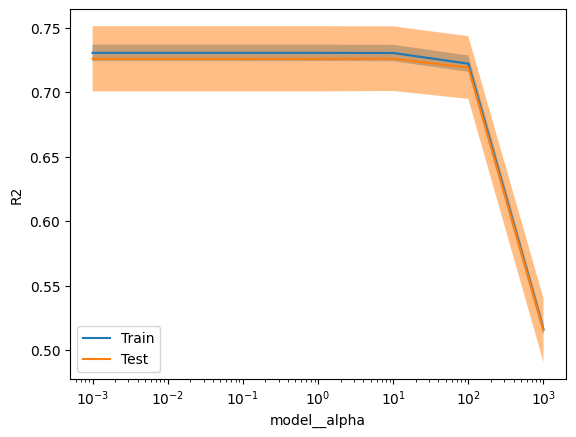

In [87]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])
ValidationCurveDisplay.from_estimator(
    pipe,
    X_train,
    y_train,
    param_name="model__alpha",
    param_range=np.logspace(-3, 3, 7),
    cv=5,
    scoring="r2",
    n_jobs=-1
)

plt.xscale("log")
plt.show()

In [88]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=42)

param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "rmse": "neg_root_mean_squared_error"
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring=scoring,
    refit="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [2, 3, 4, 5, 6, 8, 10, None],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             refit='r2',
             scoring={'mae': 'neg_mean_absolute_error',
                      'mse': 'neg_mean_squared_error', 'r2': 'r2',
                      'rmse': 'neg_root_mean_squared_error'})

In [89]:
decision_tree_best_model = grid.best_estimator_

In [90]:
y_pred = grid.predict(X_test)

print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("Test R²:", r2_score(y_test, y_pred))

Test MAE: 2613.67431280197
Test MSE: 18520451.604752976
Test RMSE: 4303.53942758202
Test R²: 0.8992117528126276


In [91]:
print("Train R²:", grid.score(X_train, y_train))
print("Test R²:", grid.score(X_test, y_test))

Train R²: 0.8553330514138986
Test R²: 0.8992117528126276


In [92]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance":decision_tree_best_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
3,smoker,0.700639
1,bmi,0.172161
0,age,0.118856
2,children,0.006912
6,region_northeast,0.001433
4,sex_female,0.000000
5,sex_male,0.000000
7,region_northwest,0.000000
8,region_southeast,0.000000
9,region_southwest,0.000000


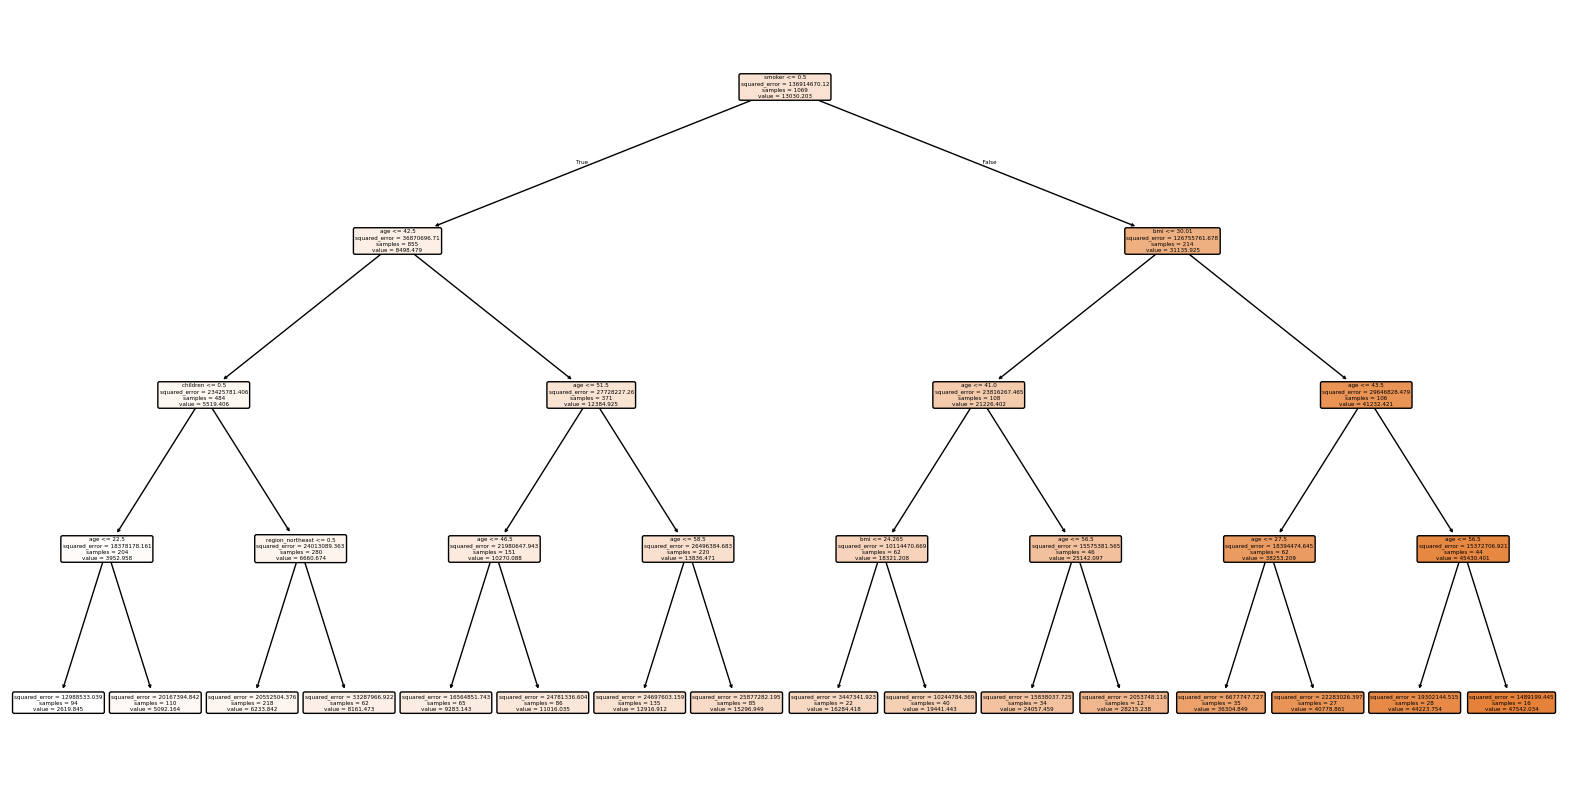

In [93]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_best_model,
    feature_names=X.columns,
    filled=True,
    rounded=True
)

plt.show()

In [94]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=1
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", None]
}

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error"
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring=scoring,
    refit="r2",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'max_features': ['sqrt', None],
                         'min_samples_leaf': [1, 2, 4],
                         'n_estimators': [100, 200]},
             refit='r2',
             scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2',
                      'rmse': 'neg_root_mean_squared_error'},
             verbose=2)

In [95]:
random_forest_best_model = grid.best_estimator_

In [96]:
y_pred = grid.predict(X_test)

print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("Test R²:", r2_score(y_test, y_pred))

Test MAE: 2365.3283045019225
Test MSE: 17677206.65315163
Test RMSE: 4204.427030304086
Test R²: 0.9038006895424257


In [97]:
print("Train R²:", grid.score(X_train, y_train))
print("Test R²:", grid.score(X_test, y_test))

Train R²: 0.8753791211584131
Test R²: 0.9038006895424257


In [98]:
results = pd.DataFrame(grid.cv_results_)

results["mean_test_mae"] = -results["mean_test_mae"]
results["mean_test_rmse"] = -results["mean_test_rmse"]

results_table = results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_leaf",
        "param_max_features",
        "mean_test_r2",
        "mean_test_mae",
        "mean_test_rmse"
    ]
].sort_values("mean_test_r2", ascending=False)

results_table.head(10)

,param_n_estimators,param_max_depth,param_min_samples_leaf,param_max_features,mean_test_r2,mean_test_mae,mean_test_rmse
11,200,5,4,None,0.846575,2564.969105,4580.112526
10,100,5,4,None,0.846507,2567.415804,4581.123519
9,200,5,2,None,0.845117,2579.112000,4602.244795
8,100,5,2,None,0.844929,2581.151652,4604.939600
7,200,5,1,None,0.843319,2594.718215,4629.275579
6,100,5,1,None,0.843295,2600.736520,4629.446817
22,100,10,4,None,0.841213,2608.191690,4660.566270
34,100,None,4,None,0.841147,2607.057556,4661.538425
23,200,10,4,None,0.841092,2615.787562,4662.294083
35,200,None,4,None,0.841012,2615.065534,4663.456249


In [99]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_best_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
3,smoker,0.681811
1,bmi,0.178195
0,age,0.123358
2,children,0.011972
6,region_northeast,0.001445
7,region_northwest,0.000983
8,region_southeast,0.000947
9,region_southwest,0.000578
5,sex_male,0.000403
4,sex_female,0.000307


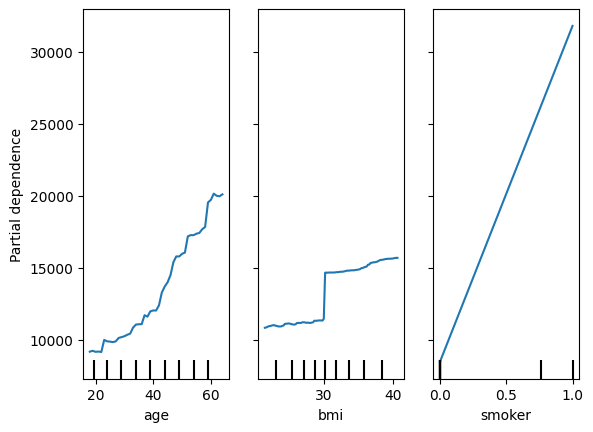

In [100]:
from sklearn.inspection import PartialDependenceDisplay
PartialDependenceDisplay.from_estimator(
    grid,
    X_train,
    features=["age", "bmi", "smoker"],
    kind="average"
)

plt.show()

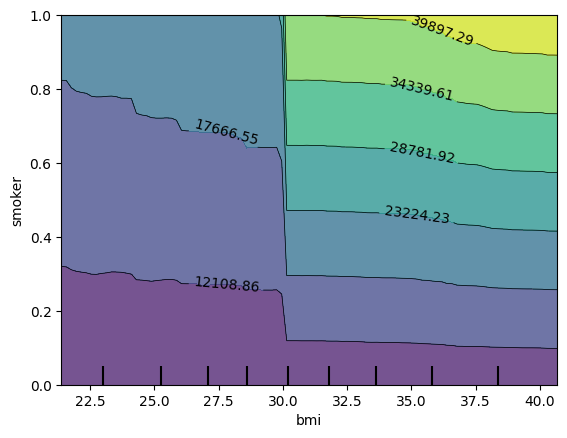

In [101]:
PartialDependenceDisplay.from_estimator(
    random_forest_best_model,
    X_train,
    features=[("bmi", "smoker")],
    kind="average"
)

plt.show()

In [104]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

model_list = [
    ("Normal Linear Regression", normal_model),
    ("Ridge (tuned)", ridge_best_model),
    ("Lasso (tuned)", lasso_best_model),
    ("Linear/Ridge/Lasso (no poly)", combined_best_model_linear_ridge_lasso_without_poly_features),
    ("Polynomial Linear/Ridge/Lasso", best_model),
    ("Decision Tree", decision_tree_best_model),
    ("Random Forest", random_forest_best_model)
]

final_results = []

for name, model in model_list:
    y_pred = model.predict(X_test)

    final_results.append({
        "Model": name,
        "Train R²": model.score(X_train, y_train),
        "Test R²": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": mean_squared_error(y_test, y_pred) ** 0.5
    })

final_results_df = pd.DataFrame(final_results)

final_results_df = final_results_df.sort_values("Test R²", ascending=False)

final_results_df

,Model,Train R²,Test R²,MAE,MSE,RMSE
6,Random Forest,0.875379,0.903801,2365.328305,1.767721e+07,4204.427030
5,Decision Tree,0.855333,0.899212,2613.674313,1.852045e+07,4303.539428
4,Polynomial Linear/Ridge/Lasso,0.833331,0.883831,2836.835983,2.134682e+07,4620.261633
0,Normal Linear Regression,0.729906,0.806929,4177.045561,3.547802e+07,5956.342894
2,Lasso (tuned),0.729899,0.806511,4179.140816,3.555469e+07,5962.775667
1,Ridge (tuned),0.729840,0.805041,4202.458449,3.582492e+07,5985.392428
3,Linear/Ridge/Lasso (no poly),0.729840,0.805041,4202.458449,3.582492e+07,5985.392428


In [105]:
final_results

[{'Model': 'Normal Linear Regression',
  'Train R²': 0.7299057809339075,
  'Test R²': 0.8069287081198011,
  'MAE': 4177.045561036326,
  'MSE': 35478020.67523561,
  'RMSE': 5956.342894363588},
 {'Model': 'Ridge (tuned)',
  'Train R²': 0.7298397965044804,
  'Test R²': 0.8050408692383275,
  'MAE': 4202.458448823848,
  'MSE': 35824922.51763896,
  'RMSE': 5985.392428040032},
 {'Model': 'Lasso (tuned)',
  'Train R²': 0.7298991839035099,
  'Test R²': 0.8065114539831848,
  'MAE': 4179.140815781409,
  'MSE': 35554693.6530851,
  'RMSE': 5962.775666842171},
 {'Model': 'Linear/Ridge/Lasso (no poly)',
  'Train R²': 0.7298397965044804,
  'Test R²': 0.8050408692383275,
  'MAE': 4202.458448823848,
  'MSE': 35824922.51763896,
  'RMSE': 5985.392428040032},
 {'Model': 'Polynomial Linear/Ridge/Lasso',
  'Train R²': 0.8333306148111841,
  'Test R²': 0.8838306769976632,
  'MAE': 2836.8359826910523,
  'MSE': 21346817.55722857,
  'RMSE': 4620.261632984497},
 {'Model': 'Decision Tree',
  'Train R²': 0.855333051